
<br>
Initializing an empty-weighted Unet and training it on the CUB dataset.<br>
Serves as a baseline model for the<br>


In [ ]:
import torch
import segmentation_models_pytorch as smp 
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import json
import sys
import os
sys.path.sappend(os.path.abspath(os.path.join(os.getcwd(), '..')))
from dataloaders import create_train_val_test_loaders

c:\Users\GAMER01\codeproj\fusionLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Hyperparams

In [2]:
MAXEPOCHS = 50
BATCHSIZE = 1
MOMENTUM = 0.99
LEARNING_RATE = 0.01
NUM_CLASSES = 2

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Model, optimizer, loss definitions -------------------------------------------------------------<br>
vanilla unet, untrained

In [4]:
unet = smp.Unet(
    encoder_name="resnet34",  
    encoder_weights=None,  
    in_channels=3,  
    classes=NUM_CLASSES,
)
unet.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [6]:
optimizer = torch.optim.SGD(unet.parameters(),
                           lr=LEARNING_RATE,
                           momentum=MOMENTUM)

In [7]:
lossFunc = torch.nn.CrossEntropyLoss()

Data loaders ------------------------------------------------------------------------------------

In [ ]:
# Change to the dir where dataloaders.py is located 

print(os.getcwd())
os.chdir(os.path.pardir)
print(os.getcwd())

c:\Users\GAMER01\codeproj\fusionLearning\baseModels\Unet_resnet34
c:\Users\GAMER01\codeproj\fusionLearning\baseModels


In [12]:
path_images_folder = os.path.join("../CUBdata/CUB_200_2011/images/")
path_segmentations_folder = os.path.join("../CUBdata/segmentations/")

In [13]:
training_dataloader, validation_dataloader, testing_dataloader = create_train_val_test_loaders(
    image_dir=path_images_folder, 
    segmentation_dir=path_segmentations_folder,
    batch_size=BATCHSIZE
)

Dataset loaded with 11788 image-segmentation pairs


# Training
- ROC-AUC only computed for validation set.
- No lr scheduler, might be something to implement later
- I think scikitlearn has a faster ROCAUC metrics class

> On an RTX 2060, training takes ~6-7 min / epoch.

__UnetV1__ - 10 epochs, no lr scheduler, unoptimized hyperparams. resnet34 encoder arch.




In [14]:
def visualize_training_process(metrics):
    """Visualize the final training process metrics"""
    plt.figure(figsize=(8, 5))
    plt.plot(metrics['epochs'], metrics['train_loss'], 'bo-', label='Training Loss')
    plt.plot(metrics['epochs'], metrics['val_loss'], 'ro-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("outputs/final_training_metrics.png")
    plt.close()


In [15]:
from tqdm import tqdm
import os
import json
from torchmetrics.classification import BinaryAUROC

# !!! TODO: Fix ROC AUC metric calculation in validation phase

def train():
    output_dir = "outputs"
    os.makedirs(output_dir, exist_ok=True)
    metrics_path = os.path.join(output_dir, "epoch_metrics.json")
    # Initialize metrics file
    with open(metrics_path, 'w') as f:
        json.dump([], f)

    best_val_loss = float('inf')
    val_auc_metric = BinaryAUROC(thresholds=128).to(device)

    for epoch in range(1, MAXEPOCHS + 1):
        # --- Training Phase ---
        unet.train()
        train_loss = 0.0
        for images, masks in tqdm(training_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Train]", leave=False, ncols=80):
            images = images.to(device)
            masks  = masks.to(device).long()

            optimizer.zero_grad()
            logits = unet(images)
            loss = lossFunc(logits, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        avg_train_loss = train_loss / len(training_dataloader)
        
        # --- Validation Phase ---
        unet.eval()
        val_loss = 0.0
        val_auc_metric.reset()
        with torch.no_grad():
            for images, masks in tqdm(validation_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Val]", leave=False, ncols=80):
                images = images.to(device)
                masks  = masks.to(device)
                logits = unet(images)
                val_loss += lossFunc(logits, masks.long()).item()

                # Ensure correct shape and type for ROC AUC
                probs = torch.softmax(logits, dim=1)[:, 1].reshape(-1)
                targets = masks.reshape(-1).float()
                val_auc_metric.update(probs, targets)

        avg_val_loss = val_loss / len(validation_dataloader)
        val_auc = val_auc_metric.compute().item()

        # Learning rate -- maybe swap to scheduler for higher convergence
        lr = LEARNING_RATE

        # save to .pth
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(unet.state_dict(), os.path.join(output_dir, 'best_model.pth'))

        # write to jason
        with open(metrics_path, 'r+') as f:
            data = json.load(f)
            data.append({
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'val_auc': val_auc,
                'lr': lr
            })
            f.seek(0)
            json.dump(data, f, indent=2)
            f.truncate()

        print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
              f"| Val AUC: {val_auc:.4f} | LR: {lr:.6f}")

    print(f"Training complete. Metrics written to {metrics_path}")


In [29]:

def test():
    unet.eval()
    tloss = 0.0


    fig, axes = plt.subplots(4, 3, figsize=(15, 10))

    with torch.no_grad():
        for image, segmentation_mask in tqdm(testing_dataloader, desc=f"[TEST]", leave=False, ncols=80):
            image = image.to(device)
            segmentation_mask = segmentation_mask.to(device)

            logits = unet(image)
            tloss += lossFunc(logits, segmentation_mask.long()).item()



    # Finalize visualization
    plt.tight_layout()
    plt.savefig("outputs/test_samples_visualization.png")
    plt.close()

    # Compute average loss and AUC
    avg_test_loss = tloss / len(testing_dataloader)

    # Save metrics
    test_metrics = {
        'test_loss': avg_test_loss,
    }
    with open('outputs/test_metrics.json', 'w') as f:
        json.dump(test_metrics, f)

    print(f"Test: Loss={avg_test_loss:.4f}")
    return test_metrics

In [30]:
import matplotlib.pyplot as plt
import json

def plot_metrics():
    with open("outputs/epoch_metrics.json", 'r') as f:
        data = json.load(f)
    epochs = [d['epoch'] for d in data]
    train_loss = [d['train_loss'] for d in data]
    val_loss = [d['val_loss'] for d in data]
    val_auc = [d['val_auc'] for d in data]
    lr = [d['lr'] for d in data]
    plt.figure(figsize=(12, 8))
    plt.subplot(2,1,1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(2,1,2)
    plt.plot(epochs, val_auc, 'r-', label='Validation ROC AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Validation ROC AUC')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("outputs/final_training_metrics.png")
    plt.show()

Model already trained. To retrain, delete the 'outputs/best_model.pth' file.
 Going ahead with testing...


Error loading image ../CUBdata/CUB_200_2011/images/091.Mockingbird\Mockingbird_0095_81177.jpg: [Errno 2] No such file or directory: '../CUBdata/CUB_200_2011/images/091.Mockingbird\\Mockingbird_0095_81177.jpg'
Error loading mask ../CUBdata/segmentations/091.Mockingbird\Mockingbird_0095_81177.png: [Errno 2] No such file or directory: '../CUBdata/segmentations/091.Mockingbird\\Mockingbird_0095_81177.png'


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

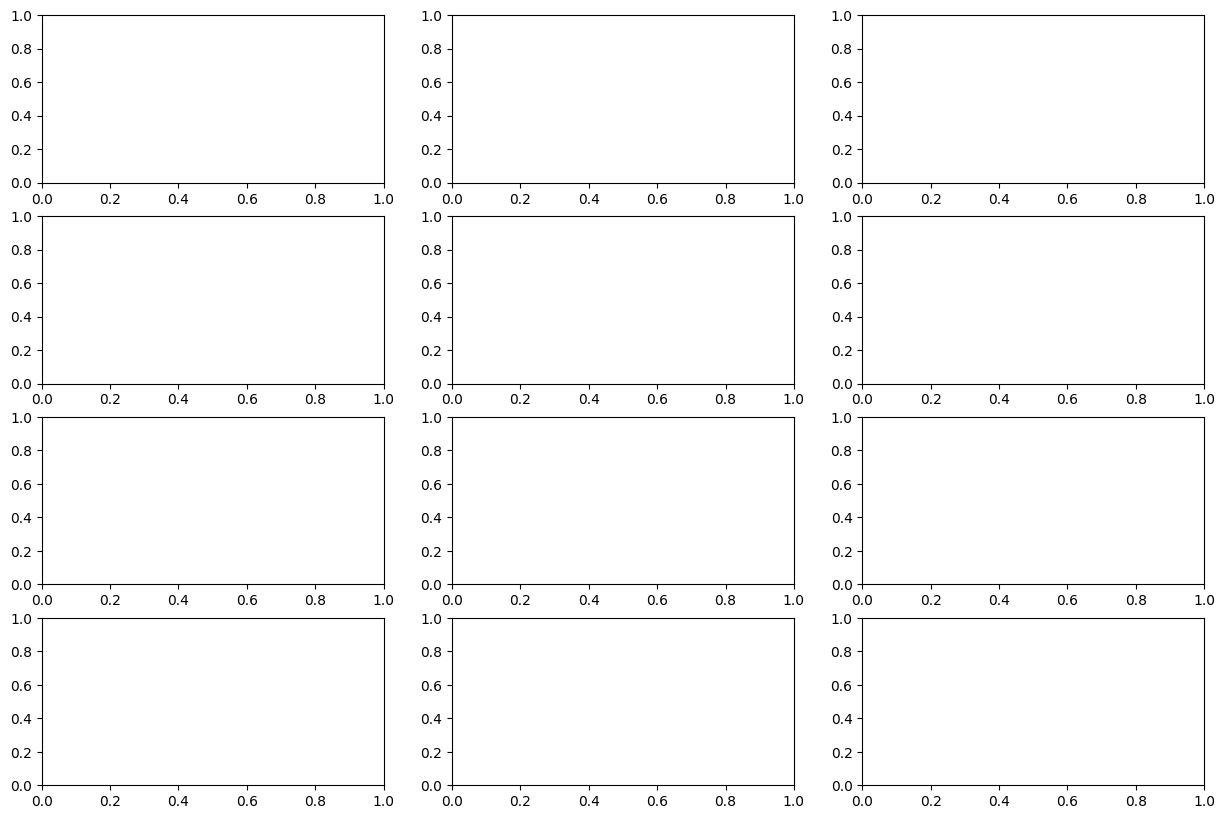

In [31]:
# chdir back to the original directory




if __name__ == "__main__":
    # Create outputs directory if it doesn't exist
    os.makedirs("outputs", exist_ok=True)
    
    if os.path.exists("./outputs/best_model.pth"):
        print("Model already trained. To retrain, delete the 'outputs/best_model.pth' file.\n Going ahead with testing...")

        # Load best model

        unet = smp.Unet(
            encoder_name="resnet34",  
            encoder_weights=None,  
            in_channels=3,  
            classes=NUM_CLASSES,
        )
        unet.load_state_dict(torch.load("outputs/best_model.pth"))
        unet.to(device)

        test_metrics = test()
        print("\nTesting completed successfully.")
        plot_metrics()
    else:
        if device.type == "cuda":
            print("Starting training process...")
            train()
            print("\nStarting testing process...")
            test_metrics = test()
            print("\nTraining and testing completed successfully.")
            print("\t * Results and visualizations saved in the 'outputs' directory. * ")

            plot_metrics()

        else:
            print("No GPU available, exiting...")

In [ ]:
import random

def inference_from_paths(testing_dataloader, n=5):
    # limit to 50 samples
    """
    Samples n random datapoints from the test set using the underlying dataset's image paths,
    loads and visualizes both the true and predicted segmentation masks.
    """
    # Try to access the dataset object and its image paths
    dataset = testing_dataloader.dataset
    if hasattr(dataset, 'dataset'):
        # This is a Subset, get the original dataset
        base_dataset = dataset.dataset
        indices = dataset.indices
        image_paths = [base_dataset.image_paths[i] for i in indices]
    else:
        image_paths = dataset.image_paths

    total_samples = len(image_paths)
    n = min(n, 50)                                          
    indices = random.sample(range(total_samples), n)

    unet.load_state_dict(torch.load("outputs/best_model.pth", map_location=device))
    unet.eval()

    plt.figure(figsize=(6, n * 3))
    for i, idx in enumerate(indices):
        # Get sample from dataset by index
        image, true_mask = dataset[idx]
        image_input = image.unsqueeze(0).to(device)
        true_mask_np = true_mask.cpu().numpy()

        with torch.no_grad():
            logits = unet(image_input)
            pred_mask = torch.argmax(logits, dim=1)[0].cpu().numpy()

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(image.cpu().permute(1, 2, 0))
        plt.title(f"Sample {i+1}: Image")
        plt.axis('off')

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(true_mask_np, cmap='gray')
        plt.title("True Mask")
        plt.axis('off')

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

 
    plt.close()


In [ ]:
inference_from_paths(testing_dataloader, n=30)

NameError: name 'testing_dataloader' is not defined